In [1]:
import time
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image

In [2]:
import tensorflow as tf

# Configure GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

GPU Memory Growth Enabled


In [3]:
input_path = "../dataset/"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest',
    horizontal_flip=True,
    preprocessing_function=preprocess_input
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=preprocess_input
)

batch_size = 128
train_set = train_datagen.flow_from_directory(
    input_path + 'train',                                          
    batch_size=batch_size,
    class_mode='categorical',
    target_size=(224,224)
)

validation_set = validation_datagen.flow_from_directory(
    input_path + 'valid',
    shuffle=False,
    batch_size=batch_size,
    class_mode='categorical',
    target_size=(224,224)
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [4]:
base_model=VGG16(weights='imagenet', include_top=False,input_shape=(224,224,3))
base_model.trainable=False

model=Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(38,activation='softmax'))
model.summary()

model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 38)                953382    
                                                                 
Total params: 15,668,070
Trainable params: 953,382
Non-trainable params: 14,714,688
_________________________________________________________________


In [5]:
train_num = train_set.samples
valid_num = validation_set.samples

In [6]:
import time

# Drop batch size to 8
batch_size = 8 

# Re-initialize the generators to apply the new batch size
train_set.batch_size = batch_size
validation_set.batch_size = batch_size

train_num = train_set.samples
valid_num = validation_set.samples

t = time.time()

history = model.fit(
    train_set,
    steps_per_epoch = train_num // batch_size,
    validation_data = validation_set,
    epochs = 5,
    validation_steps = valid_num // batch_size
)

print('Training time: %s seconds' % (time.time() - t))
print('hello this is the data sat which is to be trained right now')

Epoch 1/5
8786/8786 [==============================] - 990s 112ms/step - loss: 1.5243 - accuracy: 0.7453 - val_loss: 1.2044 - val_accuracy: 0.8461
Epoch 2/5
8786/8786 [==============================] - 1030s 117ms/step - loss: 1.2476 - accuracy: 0.8402 - val_loss: 0.8221 - val_accuracy: 0.8976
Epoch 3/5
8786/8786 [==============================] - 1083s 123ms/step - loss: 1.1535 - accuracy: 0.8665 - val_loss: 1.2086 - val_accuracy: 0.8796
Epoch 4/5
8786/8786 [==============================] - 884s 101ms/step - loss: 1.0865 - accuracy: 0.8810 - val_loss: 0.7963 - val_accuracy: 0.9215
Epoch 5/5
8786/8786 [==============================] - 1061s 121ms/step - loss: 1.0679 - accuracy: 0.8896 - val_loss: 0.7103 - val_accuracy: 0.9261
Training time: 5047.451271057129 seconds
hello this is the data sat which is to be trained right now


In [8]:
class_dict = train_set.class_indices
print(class_dict)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

In [21]:
li = list(class_dict.keys())
print(li)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [23]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


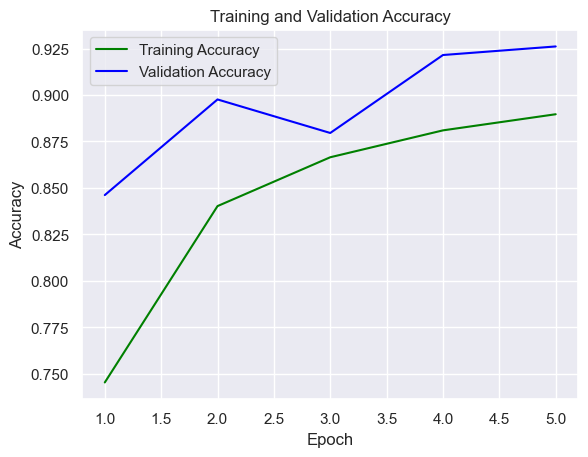

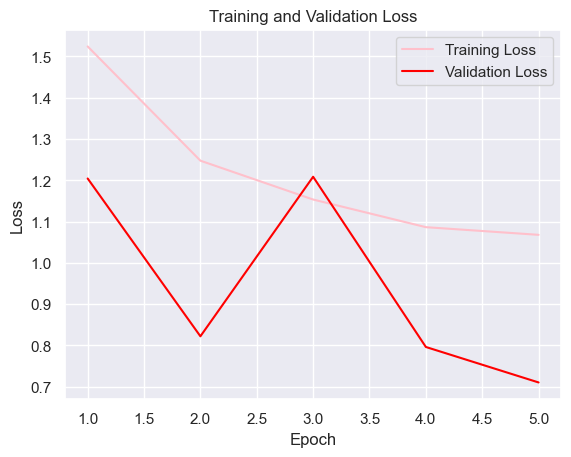

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

#accuracy plot
plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.figure()
#loss plot
plt.plot(epochs, loss, color='pink', label='Training Loss')
plt.plot(epochs, val_loss, color='red', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Following is our prediction:
1/1 [==============================] - 0s 24ms/step


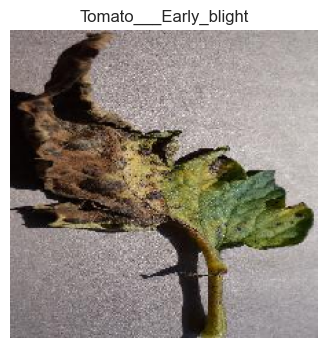

In [25]:
image_path = "../dataset/test/test/TomatoEarlyBlight1.JPG"
new_img = image.load_img(image_path, target_size=(224, 224))
img = image.img_to_array(new_img)
img = np.expand_dims(img, axis=0)
img = img/255

print("Following is our prediction:")
prediction = model.predict(img)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
d = prediction.flatten()
j = d.max()
for index,item in enumerate(d):
    if item == j:
        class_name = li[index]

#ploting image with predicted class name        
plt.figure(figsize = (4,4))
plt.imshow(new_img)
plt.axis('off')
plt.title(class_name)
plt.show()

In [16]:
filepath="Mymodel.h5"
model.save(filepath)

In [19]:
model.save("KrishiSathi_PlantModel.h5")

print("Model saved successfully as KrishiSathi_PlantModel.h5")

Model saved successfully as KrishiSathi_PlantModel.h5


In [20]:
import json

# Get the class dictionary from the training set
class_indices = train_set.class_indices

# Save it as a JSON file for your Node.js backend to use later
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)

print("Class indices saved as class_indices.json")

Class indices saved as class_indices.json
